<a href="https://colab.research.google.com/github/Immanuel1401/GitHub_Prak_ML_Kelompok-05/blob/main/Code_Prak_ML_Kelompok05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

INPUT - Loading Data & Mount Drive

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import joblib

# 1. Mount ke Google Drive
drive.mount('/content/drive')

# 2. Load Dataset dari folder Colab Notebooks
path_data = '/content/drive/MyDrive/Colab Notebooks/PRSA_data_2010.1.1-2014.12.31.csv'
df = pd.read_csv(path_data)

# Menampilkan struktur data awal
print("--- Tampilan Struktur Data Awal ---")
print(df.info())
print("\n--- 5 Baris Pertama Dataset ---")
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Tampilan Struktur Data Awal ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  object 
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 4.3+ MB
None

--- 5 Baris Pertama Dataset ---
   No  year  month  day  hour  pm2.5  DEWP  TEMP    PRES cbwd    Iws  I

PREPROCESSING - Missing Values & Encoding

In [ ]:
# 1. Menangani Missing Values pada target pm2.5 dengan Linear Interpolation
df['pm2.5'] = df['pm2.5'].interpolate(method='linear')
df['pm2.5'] = df['pm2.5'].fillna(method='bfill')

# 2. Merapikan datetime index agar sekuensial temporal
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df.set_index('datetime', inplace=True)
df.drop(['No', 'year', 'month', 'day', 'hour'], axis=1, inplace=True)

# 3. One-Hot Encoding untuk fitur kategorikal arah angin (cbwd)
df = pd.get_dummies(df, columns=['cbwd'], drop_first=True)

print("--- Hasil Check Missing Value Setelah Preprocessing ---")
print(df.isnull().sum())

--- Hasil Check Missing Value Setelah Preprocessing ---
pm2.5      0
DEWP       0
TEMP       0
PRES       0
Iws        0
Is         0
Ir         0
cbwd_NW    0
cbwd_SE    0
cbwd_cv    0
dtype: int64


/tmp/ipykernel_502/204548952.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['pm2.5'] = df['pm2.5'].fillna(method='bfill')


TRANSFORMATION - Scaling & Sliding Window

In [ ]:
# 1. Feature Scaling menggunakan MinMaxScaler (0-1)
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# Menyimpan objek scaler ke Drive
joblib.dump(scaler, '/content/drive/MyDrive/Colab Notebooks/scaler_pm25.pkl')

# 2. Fungsi Pembuatan Sliding Window (24 Jam terakhir -> Prediksi 1 Jam ke depan)
def create_windowed_data(data, target_col_idx, window_size=24):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), :])           # Input: 24 jam ke belakang
        y.append(data[i + window_size, target_col_idx])  # Target: 1 jam ke depan
    return np.array(X), np.array(y)

# pm2.5 berada di kolom indeks 0 setelah drop
X, y = create_windowed_data(scaled_data, target_col_idx=0, window_size=24)

print("--- Dimensi Data Setelah Transformation ---")
print(f"Bentuk Dimensi X (Samples, Time Steps, Features): {X.shape}")
print(f"Bentuk Dimensi y (Target): {y.shape}")

--- Dimensi Data Setelah Transformation ---
Bentuk Dimensi X (Samples, Time Steps, Features): (43800, 24, 10)
Bentuk Dimensi y (Target): (43800,)


DATA SPLITTING - 80:10:10 Sekuensial

In [ ]:
# Menghitung rasio split secara berurutan waktu (Tanpa Shuffle)
train_size = int(len(X) * 0.8)
val_size = int(len(X) * 0.1)

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]

# Ekspor otomatis hasil split ke format .npy di Drive
np.save('/content/drive/MyDrive/Colab Notebooks/X_train.npy', X_train)
np.save('/content/drive/MyDrive/Colab Notebooks/y_train.npy', y_train)
np.save('/content/drive/MyDrive/Colab Notebooks/X_val.npy', X_val)
np.save('/content/drive/MyDrive/Colab Notebooks/y_val.npy', y_val)
np.save('/content/drive/MyDrive/Colab Notebooks/X_test.npy', X_test)
np.save('/content/drive/MyDrive/Colab Notebooks/y_test.npy', y_test)

print("--- Hasil Pembagian Data Pipeline ---")
print(f"Train set : {X_train.shape}")
print(f"Val set   : {X_val.shape}")
print(f"Test set  : {X_test.shape}")

--- Hasil Pembagian Data Pipeline ---
Train set : (35040, 24, 10)
Val set   : (4380, 24, 10)
Test set  : (4380, 24, 10)


METODE DEEP LEARNING 1 - LSTM & Training

--- Ringkasan Arsitektur LSTM ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 24, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,161 (125.63 KB)

 Trainable params: 32,161 (125.63 KB)

 Non-trainable params: 0 (0.00 B)


--- Memulai Proses Training Model ---
Epoch 1/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - loss: 0.0030 - mae: 0.0365 - val_loss: 0.0020 - val_mae: 0.0291
Epoch 2/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - loss: 0.0016 - mae: 0.0261 - val_loss: 0.0011 - val_mae: 0.0211
Epoch 3/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - loss: 0.0012 - mae: 0.0218 - val_loss: 0.0012 - val_mae: 0.0208
Epoch 4/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - loss: 9.8031e-04 - mae: 0.0197 - val_loss: 0.0011 - val_mae: 0.0201
Epoch 5/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 17s 30ms/step - loss: 8.5767e-04 - mae: 0.0184 - val_loss: 8.0700e-04 - val_mae: 0.0175
Epoch 6/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 17s 30ms/step - loss: 7.9451e-04 - mae: 0.0174 - val_loss: 9.2425e-04 - val_mae: 0.0187
Epoch 7/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - loss: 7.5173e-04 - mae: 0.0169 - val_loss: 8.8914e-04 - val_mae: 0.0177
Epoch 8/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - loss: 7.0720e-04 - mae: 0.0163 - val_

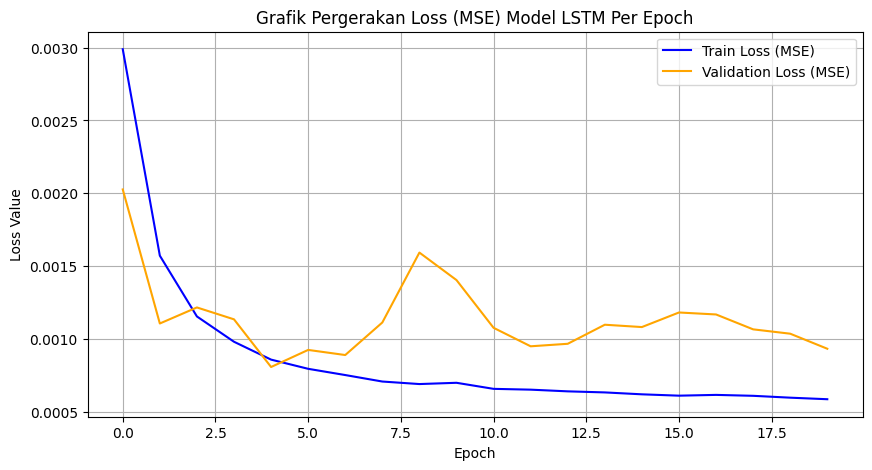

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. Membangun Arsitektur Model
model_lstm = Sequential([
    LSTM(64, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='relu', return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1) # Output layer untuk nilai regresi kontinu
])

model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("--- Ringkasan Arsitektur LSTM ---")
model_lstm.summary()

# 2. Proses Pelatihan Model (Training)
print("\n--- Memulai Proses Training Model ---")
history = model_lstm.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

# 3. Menyimpan file model terbaik ke Drive
model_lstm.save('/content/drive/MyDrive/Colab Notebooks/model_lstm_beijing.keras')

# 4. Membuat Visualisasi Grafik Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss (MSE)', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='orange')
plt.title('Grafik Pergerakan Loss (MSE) Model LSTM Per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)
plt.savefig('/content/drive/MyDrive/Colab Notebooks/grafik_loss_lstm.png')
plt.show()

LOAD DATA PIPELINE

In [ ]:
from google.colab import drive
import numpy as np
import joblib

drive.mount('/content/drive')
path = '/content/drive/MyDrive/Colab Notebooks/'

X_train = np.load(path + 'X_train.npy')
y_train = np.load(path + 'y_train.npy')
X_val   = np.load(path + 'X_val.npy')
y_val   = np.load(path + 'y_val.npy')
X_test  = np.load(path + 'X_test.npy')
y_test  = np.load(path + 'y_test.npy')
scaler  = joblib.load(path + 'scaler_pm25.pkl')

print('X_train:', X_train.shape)
print('X_val  :', X_val.shape)
print('X_test :', X_test.shape)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
X_train: (35040, 24, 10)
X_val  : (4380, 24, 10)
X_test : (4380, 24, 10)


ARSITEKTUR MODEL 1D-CNN

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

model_cnn = Sequential([
    Conv1D(64, kernel_size=3, activation='relu',
           input_shape=(X_train.shape[1], X_train.shape[2])),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    Conv1D(32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    Flatten(),
    Dense(16, activation='relu'),
    Dense(1)  # Output layer untuk nilai regresi kontinu
])

model_cnn.compile(optimizer='adam', loss='mse', metrics=['mae'])
print('--- Ringkasan Arsitektur CNN ---')
model_cnn.summary()


--- Ringkasan Arsitektur CNN ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 22, 64)         │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 11, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 11, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 9, 32)          │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,241 (40.00 KB)

 Trainable params: 10,241 (40.00 KB)

 Non-trainable params: 0 (0.00 B)

TRAINING MODEL 1D-CNN

--- Proses Training Model CNN ---
Epoch 1/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0067 - mae: 0.0544 - val_loss: 0.0037 - val_mae: 0.0410
Epoch 2/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0035 - mae: 0.0407 - val_loss: 0.0033 - val_mae: 0.0383
Epoch 3/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0032 - mae: 0.0380 - val_loss: 0.0030 - val_mae: 0.0371
Epoch 4/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0029 - mae: 0.0361 - val_loss: 0.0028 - val_mae: 0.0354
Epoch 5/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0027 - mae: 0.0346 - val_loss: 0.0032 - val_mae: 0.0366
Epoch 6/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0026 - mae: 0.0336 - val_loss: 0.0027 - val_mae: 0.0353
Epoch 7/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0025 - mae: 0.0330 - val_loss: 0.0027 - val_mae: 0.0343
Epoch 8/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0023 - mae: 0.0319 - val_loss: 0.0025 - val_mae: 0.0328
Epoch 9/20
548/548 ━

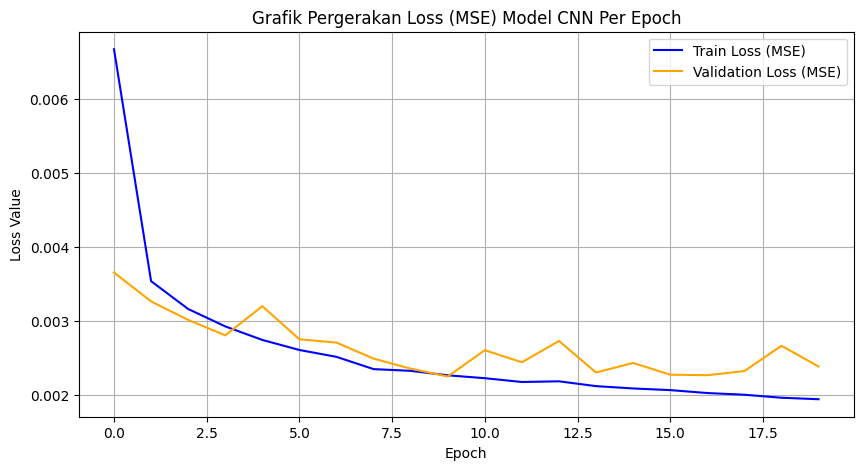

In [ ]:
print('--- Proses Training Model CNN ---')
history_cnn = model_cnn.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

model_cnn.save(path + 'model_cnn_beijing.keras')

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(history_cnn.history['loss'], label='Train Loss (MSE)', color='blue')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss (MSE)', color='orange')
plt.title('Grafik Pergerakan Loss (MSE) Model CNN Per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)
plt.savefig(path + 'grafik_loss_cnn.png')
plt.show()


FUNGSI EVALUASI & INVERSE SCALING

In [ ]:

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf


path = '/content/drive/MyDrive/Colab Notebooks/'

def inverse_pm25(values_scaled, scaler, n_features=10, target_idx=0):
    dummy = np.zeros((len(values_scaled), n_features))
    dummy[:, target_idx] = values_scaled
    return scaler.inverse_transform(dummy)[:, target_idx]

def evaluate_model(model, X_test, y_test, scaler):
    y_pred_scaled = model.predict(X_test).flatten()
    y_test_asli = inverse_pm25(y_test, scaler)
    y_pred_asli = inverse_pm25(y_pred_scaled, scaler)

    mse  = mean_squared_error(y_test_asli, y_pred_asli)
    mae  = mean_absolute_error(y_test_asli, y_pred_asli)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test_asli, y_pred_asli)
    return mse, mae, rmse, r2, y_test_asli, y_pred_asli


model_lstm = tf.keras.models.load_model(path + 'model_lstm_beijing.keras')


mse_l, mae_l, rmse_l, r2_l, y_asli_l, y_pred_l = evaluate_model(model_lstm, X_test, y_test, scaler)
mse_c, mae_c, rmse_c, r2_c, y_asli_c, y_pred_c = evaluate_model(model_cnn,  X_test, y_test, scaler)

print('=== LSTM ===')
print(f'MSE : {mse_l:.4f} | MAE : {mae_l:.4f} | RMSE : {rmse_l:.4f} | R2 : {r2_l:.4f}')
print('=== CNN ===')
print(f'MSE : {mse_c:.4f} | MAE : {mae_c:.4f} | RMSE : {rmse_c:.4f} | R2 : {r2_c:.4f}')

137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
=== LSTM ===
MSE : 629.7118 | MAE : 17.3723 | RMSE : 25.0941 | R2 : 0.9221
=== CNN ===
MSE : 1848.0203 | MAE : 31.7349 | RMSE : 42.9886 | R2 : 0.7715


GRAFIK PREDIKSI DENGAN AKTUAL

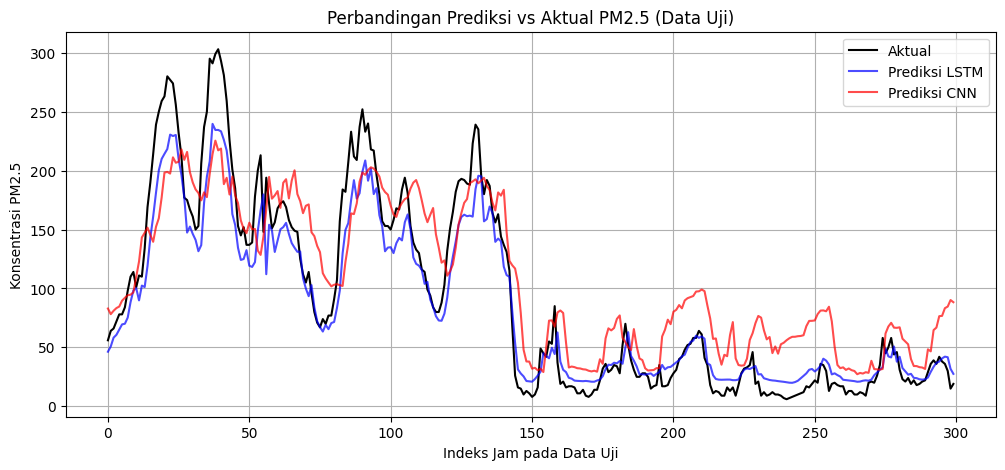

In [ ]:
import matplotlib.pyplot as plt

n_tampil = 300

plt.figure(figsize=(12, 5))
plt.plot(y_asli_l[:n_tampil], label='Aktual', color='black', linewidth=1.5)
plt.plot(y_pred_l[:n_tampil], label='Prediksi LSTM', color='blue', alpha=0.7)
plt.plot(y_pred_c[:n_tampil], label='Prediksi CNN', color='red', alpha=0.7)
plt.title('Perbandingan Prediksi vs Aktual PM2.5 (Data Uji)')
plt.xlabel('Indeks Jam pada Data Uji')
plt.ylabel('Konsentrasi PM2.5')
plt.legend()
plt.grid(True)
plt.savefig(path + 'grafik_prediksi_vs_aktual.png')
plt.show()


GRAFIK ERROR (RESIDUAL)

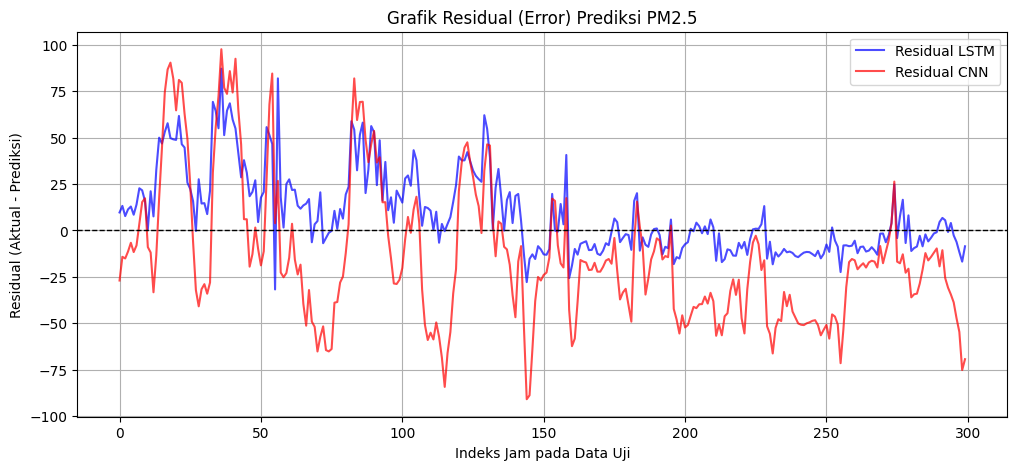

In [ ]:
residual_lstm = y_asli_l - y_pred_l
residual_cnn  = y_asli_c - y_pred_c

plt.figure(figsize=(12, 5))
plt.plot(residual_lstm[:n_tampil], label='Residual LSTM', color='blue', alpha=0.7)
plt.plot(residual_cnn[:n_tampil],  label='Residual CNN',  color='red',  alpha=0.7)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Grafik Residual (Error) Prediksi PM2.5')
plt.xlabel('Indeks Jam pada Data Uji')
plt.ylabel('Residual (Aktual - Prediksi)')
plt.legend()
plt.grid(True)
plt.savefig(path + 'grafik_residual.png')
plt.show()


MODEL TERBAIK (LSTM)

In [ ]:
model_terbaik = model_lstm
model_terbaik.save(path + 'model_terbaik.keras')

window_buffer_23jam = X_test[-1][1:]
np.save(path + 'window_buffer_23jam.npy', window_buffer_23jam)
print('Model terbaik dan buffer riwayat berhasil disiapkan untuk deployment.')


Model terbaik dan buffer riwayat berhasil disiapkan untuk deployment.


ANTARMUKA

In [ ]:
import os

os.makedirs('templates', exist_ok=True)

html_code = """
<!DOCTYPE html>
<html lang='id'>
<head>
  <meta charset='UTF-8'>
  <meta name='viewport' content='width=device-width, initial-scale=1.0'>
  <title>Prediksi PM2.5 Dashboard</title>
  <link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;600;800&display=swap" rel="stylesheet">
  <style>
    body {
        font-family: 'Inter', sans-serif;
        background-color: #F6F8F6; /* Off-white lembut */
        margin: 0;
        color: #1A3626; /* Hijau tua gelap untuk teks */
    }
    .navbar {
        background: white;
        padding: 20px 40px;
        border-radius: 0 0 30px 30px;
        box-shadow: 0 4px 15px rgba(0,0,0,0.03);
        margin-bottom: 30px;
        display: flex;
        align-items: center;
    }
    .navbar h1 {
        margin: 0;
        font-size: 22px;
        font-weight: 800;
        color: #247B44;
    }
    .main-container {
        max-width: 1000px;
        margin: 0 auto;
        padding: 0 20px;
        display: flex;
        gap: 30px;
        flex-wrap: wrap;
    }
    .left-panel {
        flex: 2;
        min-width: 300px;
    }
    .right-panel {
        flex: 1;
        min-width: 300px;
    }
    .card {
        background: #ffffff;
        border-radius: 24px;
        padding: 30px;
        box-shadow: 0 10px 30px rgba(0,0,0,0.04);
    }
    h2.section-title {
        font-size: 24px;
        font-weight: 800;
        margin-top: 0;
        margin-bottom: 25px;
    }
    .input-grid {
        display: grid;
        grid-template-columns: 1fr 1fr;
        gap: 15px;
    }
    label {
        font-size: 13px;
        font-weight: 600;
        color: #4A6355;
        display: block;
        margin-bottom: 5px;
    }
    input, select {
        width: 100%;
        padding: 12px 15px;
        border-radius: 12px;
        border: 1px solid #E0E7E2;
        box-sizing: border-box;
        background: #F9FBF9;
        font-family: 'Inter', sans-serif;
    }
    input:focus, select:focus {
        outline: none;
        border-color: #247B44;
    }
    .full-width {
        grid-column: span 2;
    }
    button {
        width: 100%;
        padding: 16px;
        margin-top: 25px;
        background: linear-gradient(135deg, #247B44, #2A88A0);
        color: #fff;
        border: none;
        border-radius: 16px;
        font-size: 16px;
        font-weight: 600;
        cursor: pointer;
        transition: opacity 0.3s;
    }
    button:hover {
        opacity: 0.9;
    }
    .stats-card {
        background: linear-gradient(135deg, #247B44, #3B9CB0);
        border-radius: 24px;
        padding: 30px;
        color: white;
        box-shadow: 0 15px 35px rgba(36, 123, 68, 0.2);
    }
    .stats-card h3 {
        margin: 0 0 5px 0;
        font-size: 16px;
        font-weight: 600;
        opacity: 0.9;
    }
    .stats-card .location {
        font-size: 28px;
        font-weight: 800;
        margin-bottom: 30px;
    }
    .metric-box {
        background: rgba(255, 255, 255, 0.15);
        border-radius: 16px;
        padding: 15px 20px;
        margin-bottom: 15px;
        backdrop-filter: blur(10px);
    }
    .metric-box p {
        margin: 0;
        font-size: 13px;
        opacity: 0.9;
    }
    .metric-box h4 {
        margin: 5px 0 0 0;
        font-size: 24px;
        font-weight: 800;
    }
  </style>
</head>
<body>

  <div class="navbar">
    <h1>🍃 PM2.5 Eco-Dashboard</h1>
  </div>

  <div class='main-container'>

    <!-- Bagian Kiri: Form Input -->
    <div class="left-panel">
        <div class='card'>
        <h2 class="section-title">Parameter Lingkungan</h2>
        <form method='POST'>
            <div class="input-grid">
                <div class="full-width">
                    <label>PM2.5 Jam Sebelumnya (&micro;g/m&sup3;)</label>
                    <input type='number' step='0.1' name='pm25_terakhir' required>
                </div>
                <div>
                    <label>Titik Embun (&deg;C)</label>
                    <input type='number' step='0.1' name='dewp' required>
                </div>
                <div>
                    <label>Suhu Udara (&deg;C)</label>
                    <input type='number' step='0.1' name='temp' required>
                </div>
                <div>
                    <label>Tekanan (hPa)</label>
                    <input type='number' step='0.1' name='pres' required>
                </div>
                <div>
                    <label>Kec. Angin / Iws</label>
                    <input type='number' step='0.1' name='iws' required>
                </div>
                <div>
                    <label>Curah Salju (jam)</label>
                    <input type='number' step='1' name='is_' required>
                </div>
                <div>
                    <label>Curah Hujan (jam)</label>
                    <input type='number' step='1' name='ir' required>
                </div>
                <div class="full-width">
                    <label>Arah Angin</label>
                    <select name='cbwd'>
                        <option value='NW'>Barat Laut (NW)</option>
                        <option value='SE'>Tenggara (SE)</option>
                        <option value='cv'>Bervariasi (cv)</option>
                        <option value='NE'>Timur Laut (NE)</option>
                    </select>
                </div>
            </div>
            <button type='submit'>Analisis Kualitas Udara</button>
        </form>
        </div>
    </div>

    <!-- Bagian Kanan: Hasil Prediksi (Live Stats) -->
    <div class="right-panel">
        <div class="stats-card">
            <h3>LIVE ECO-STATS</h3>
            <div class="location">Beijing, CN</div>

            {% if hasil is not none %}
                <div class="metric-box" style="background: {{ warna }}; box-shadow: 0 4px 15px rgba(0,0,0,0.2);">
                    <p>Prediksi Konsentrasi PM2.5</p>
                    <h4>{{ hasil }} &micro;g/m&sup3;</h4>
                </div>
                <div class="metric-box">
                    <p>Status Kualitas Udara</p>
                    <h4>{{ kategori }}</h4>
                </div>
            {% else %}
                <div class="metric-box">
                    <p>Menunggu Input...</p>
                    <h4>-- &micro;g/m&sup3;</h4>
                </div>
            {% endif %}
        </div>
    </div>

  </div>

</body>
</html>
"""

with open('templates/index.html', 'w') as f:
    f.write(html_code)

print("Desain GreenLink UI berhasil diimplementasikan ke index.html!")

Desain GreenLink UI berhasil diimplementasikan ke index.html!


BACKEND (FLASK)

In [ ]:
# app.py - Backend GUI Mobile
from flask import Flask, render_template, request
import numpy as np
import joblib
import tensorflow as tf

app = Flask(__name__)

path = '/content/drive/MyDrive/Colab Notebooks/'

model  = tf.keras.models.load_model(path + 'model_terbaik.keras')
scaler = joblib.load(path + 'scaler_pm25.pkl')
window_buffer = np.load(path + 'window_buffer_23jam.npy')  # shape (23, 10)

def kategori_kualitas_udara(nilai):
    if nilai <= 50:
        return 'Baik', '#2ecc71'
    elif nilai <= 100:
        return 'Sedang', '#f1c40f'
    elif nilai <= 150:
        return 'Tidak Sehat bagi Kelompok Sensitif', '#e67e22'
    elif nilai <= 200:
        return 'Tidak Sehat', '#e74c3c'
    else:
        return 'Berbahaya', '#8e44ad'

@app.route('/', methods=['GET', 'POST'])
def index():
    hasil = None
    kategori = None
    warna = None
    if request.method == 'POST':
        pm25_terakhir = float(request.form['pm25_terakhir'])
        dewp = float(request.form['dewp'])
        temp = float(request.form['temp'])
        pres = float(request.form['pres'])
        iws  = float(request.form['iws'])
        is_  = float(request.form['is_'])
        ir   = float(request.form['ir'])
        arah = request.form['cbwd']

        cbwd_nw = 1 if arah == 'NW' else 0
        cbwd_se = 1 if arah == 'SE' else 0
        cbwd_cv = 1 if arah == 'cv' else 0

        baris_baru = np.array([[pm25_terakhir, dewp, temp, pres,
                                 iws, is_, ir, cbwd_nw, cbwd_se, cbwd_cv]])
        baris_scaled = scaler.transform(baris_baru)

        window_input = np.vstack([window_buffer, baris_scaled]).reshape(1, 24, 10)
        pred_scaled = model.predict(window_input)[0][0]

        dummy = np.zeros((1, 10))
        dummy[0, 0] = pred_scaled
        hasil = round(float(scaler.inverse_transform(dummy)[0, 0]), 2)
        kategori, warna = kategori_kualitas_udara(hasil)

    return render_template('index.html', hasil=hasil, kategori=kategori, warna=warna)

if __name__ == '__main__':
    app.run()


 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [04/Jul/2026 19:40:09] "GET / HTTP/1.1" 200 -
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step


INFO:werkzeug:127.0.0.1 - - [04/Jul/2026 19:41:10] "POST / HTTP/1.1" 200 -


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
INFO:werkzeug:127.0.0.1 - - [04/Jul/2026 20:19:02] "POST / HTTP/1.1" 200 -


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
INFO:werkzeug:127.0.0.1 - - [04/Jul/2026 20:23:05] "POST / HTTP/1.1" 200 -


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
INFO:werkzeug:127.0.0.1 - - [04/Jul/2026 20:28:04] "POST / HTTP/1.1" 200 -


NGROK

In [ ]:
!pip install flask pyngrok --quiet

from pyngrok import ngrok

ngrok.set_auth_token('3G3GIfW2a2HY1xF1x52oy0o6XjF_3s8hhSdfezLKpMAhZ9F1q')  # daftar gratis di ngrok.com
public_url = ngrok.connect(5000)
print('Buka tautan berikut dari HP:', public_url)

!python app.py


Buka tautan berikut dari HP: NgrokTunnel: "https://regime-humbly-daisy.ngrok-free.dev" -> "http://localhost:5000"
python3: can't open file '/content/app.py': [Errno 2] No such file or directory
